
Tolerance = 0.001
Jacobi iterations: 4
Gauss-Seidel iterations: 4


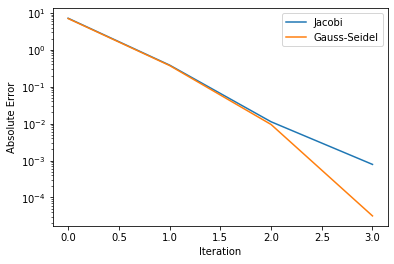


Tolerance = 1e-06
Jacobi iterations: 7
Gauss-Seidel iterations: 5


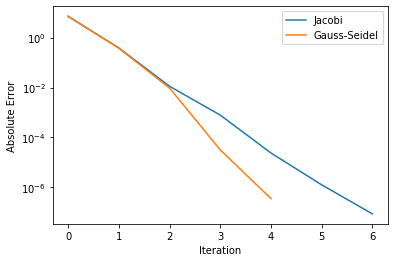


Tolerance = 1e-09
Jacobi iterations: 9
Gauss-Seidel iterations: 7


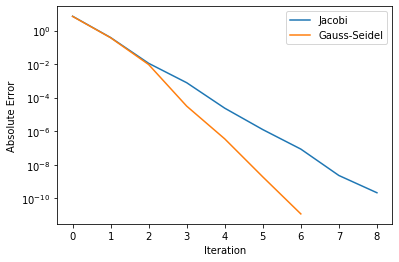

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Gauss-Seidel
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_old = x.copy()

        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]

        error = np.linalg.norm(x - x_old, ord=np.inf)
        errors.append(error)

        if error < tol:
            return x, k+1, errors

    return x, max_iterations, errors


# Jacobi
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iterations):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        error = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(error)

        if error < tol:
            return x_new, k+1, errors

        x = x_new

    return x, max_iterations, errors


A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]])

b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
max_iterations = 100

tolerances = [1e-3, 1e-6, 1e-9]

for tol in tolerances:

    solutionJACOBI, iterationsJACOBI, errorJACOBI = jacobi(A, b, x0, tol, max_iterations)
    solutionGAUSS, iterationsGAUSS, errorGAUSS = gauss_seidel(A, b, x0, tol, max_iterations)

    print(f"\nTolerance = {tol}")
    print("Jacobi iterations:", iterationsJACOBI)
    print("Gauss-Seidel iterations:", iterationsGAUSS)

    plt.figure()
    plt.semilogy(errorJACOBI, label="Jacobi")
    plt.semilogy(errorGAUSS, label="Gauss-Seidel")
    plt.xlabel("Iteration")
    plt.ylabel("Absolute Error")
    plt.legend()
    plt.show()